# 02 — Treinamento NER com spaCy

Quatro configurações são treinadas para permitir a comparação sistemática solicitada na atividade.

In [ ]:
import json, random
from pathlib import Path
import spacy
from spacy.training import Example
from spacy.util import minibatch

def load_jsonl(path):
    with open(path,encoding="utf-8") as f: return [json.loads(x) for x in f]
train_data=load_jsonl("../data/processed/tv_train.jsonl")
LABELS=["PRODUTO","MARCA","TAMANHO","TECNOLOGIA","RESOLUCAO","RECURSO","REFERENCIA"]
print("Treino:",len(train_data))

In [ ]:
#4 experimento com diferentes épocas
EXPERIMENTS=[
 {"id":"EXP-01","epochs":10,"dropout":0.2},
 {"id":"EXP-02","epochs":20,"dropout":0.2},
 {"id":"EXP-03","epochs":30,"dropout":0.2},
 {"id":"EXP-04","epochs":20,"dropout":0.3},
]
EXPERIMENTS

In [13]:
def train_experiment(data,exp,seed=42):
    random.seed(seed)
    nlp=spacy.blank("pt")
    ner=nlp.add_pipe("ner")
    for label in LABELS: ner.add_label(label)
    examples=[Example.from_dict(nlp.make_doc(x["text"]),{"entities":x["entities"]}) for x in data]
    optimizer=nlp.initialize(get_examples=lambda: examples)
    losses=[]
    for epoch in range(exp["epochs"]):
        random.shuffle(examples); loss={}
        for batch in minibatch(examples,size=8):
            nlp.update(batch,drop=exp["dropout"],losses=loss)
        losses.append(loss.get("ner",0.0))
    return nlp,losses

In [14]:
models_dir=Path("../models"); models_dir.mkdir(exist_ok=True)
training_history={}
for exp in EXPERIMENTS:
    print("Treinando",exp["id"])
    model,losses=train_experiment(train_data,exp)
    model.to_disk(models_dir/exp["id"])
    training_history[exp["id"]]=losses
print("Concluído.")

Treinando EXP-01
Treinando EXP-02
Treinando EXP-03
Treinando EXP-04
Concluído.


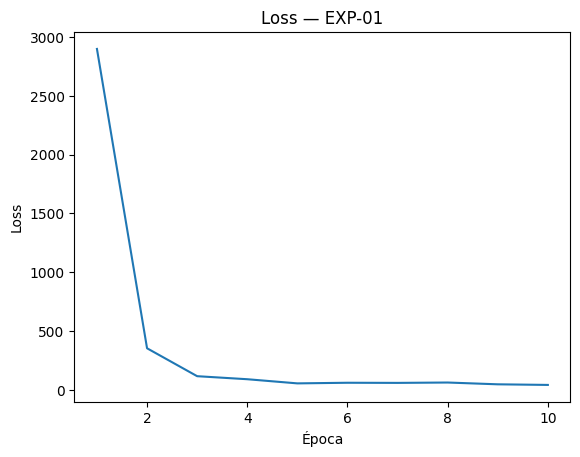

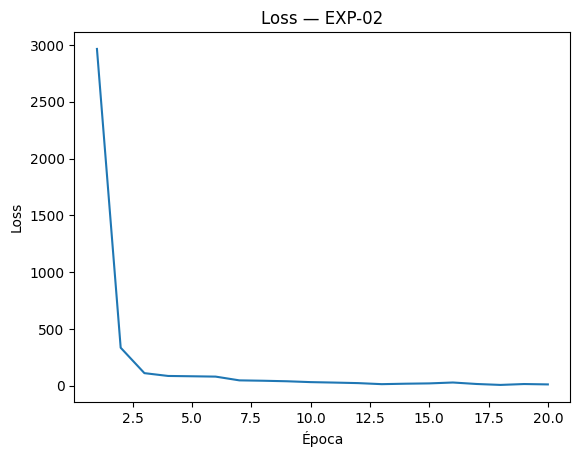

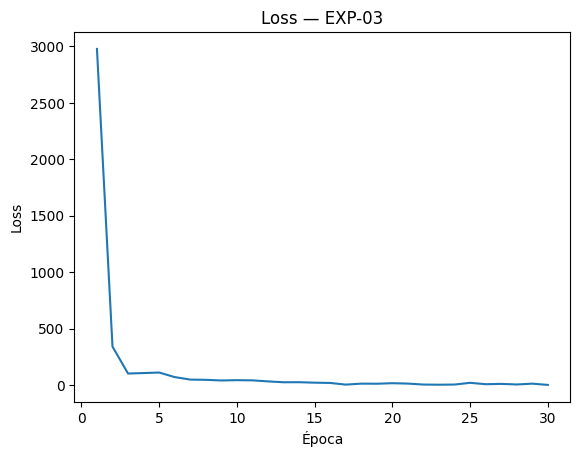

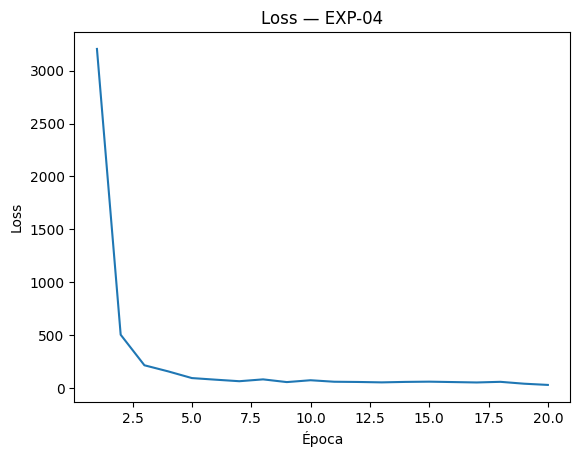

In [19]:
import matplotlib.pyplot as plt
for exp_id,losses in training_history.items():
    plt.figure()
    plt.plot(range(1,len(losses)+1),losses)
    plt.title(f"Loss — {exp_id}")
    plt.xlabel("Época"); plt.ylabel("Loss")
    plt.show()

In [20]:
import numpy as np

# Convert np.float32 values to standard Python floats
serializable_training_history = {}
for exp_id, losses in training_history.items():
    serializable_training_history[exp_id] = [float(loss) for loss in losses]

with open("../models/training_history.json","w") as f: json.dump(serializable_training_history,f)
print("Histórico salvo.")

Histórico salvo.


In [21]:
import json
from pathlib import Path
from collections import defaultdict
import spacy
import pandas as pd
import matplotlib.pyplot as plt

def load_jsonl(path):
    with open(path,encoding="utf-8") as f: return [json.loads(x) for x in f]
test_data=load_jsonl("../data/processed/tv_test.jsonl")
MODELS=Path("../models")
print("Teste:",len(test_data))

Teste: 164


In [22]:
def evaluate_model(nlp,data):
    gold_total=pred_total=tp=0
    gold=defaultdict(int); pred=defaultdict(int); hits=defaultdict(int)
    errors=[]
    for item in data:
        g={(s,e,l) for s,e,l in item["entities"]}
        d=nlp(item["text"])
        p={(e.start_char,e.end_char,e.label_) for e in d.ents}
        gold_total+=len(g); pred_total+=len(p); tp+=len(g&p)
        for _,_,l in g: gold[l]+=1
        for _,_,l in p: pred[l]+=1
        for _,_,l in g&p: hits[l]+=1
        if g!=p: errors.append((item["text"],g,p))
    precision=tp/pred_total if pred_total else 0
    recall=tp/gold_total if gold_total else 0
    f1=2*precision*recall/(precision+recall) if precision+recall else 0
    per={}
    for l in sorted(set(gold)|set(pred)):
        p=hits[l]/pred[l] if pred[l] else 0
        r=hits[l]/gold[l] if gold[l] else 0
        f=2*p*r/(p+r) if p+r else 0
        per[l]={"precision":p,"recall":r,"f1":f}
    return {"precision":precision,"recall":recall,"f1":f1,"per_label":per,"errors":errors}

In [23]:
results={}
for exp_id in ["EXP-01","EXP-02","EXP-03","EXP-04"]:
    results[exp_id]=evaluate_model(spacy.load(MODELS/exp_id),test_data)
    r=results[exp_id]
    print(f"{exp_id}: Precision={r['precision']:.4f} | Recall={r['recall']:.4f} | F1={r['f1']:.4f}")

EXP-01: Precision=0.9953 | Recall=0.9938 | F1=0.9946
EXP-02: Precision=0.9846 | Recall=0.9922 | F1=0.9884
EXP-03: Precision=0.9891 | Recall=0.9876 | F1=0.9883
EXP-04: Precision=0.9815 | Recall=0.9922 | F1=0.9869


In [ ]:
comparison=pd.DataFrame([{"Experimento":k,"Precision":v["precision"],"Recall":v["recall"],"F1":v["f1"]} for k,v in results.items()])
comparison

In [ ]:
rows=[]
for exp,r in results.items():
    for label,m in r["per_label"].items():
        rows.append({"Experimento":exp,"TAG":label,**m})
pd.DataFrame(rows).sort_values(["TAG","f1"],ascending=[True,False])

In [ ]:
ax=comparison.set_index("Experimento")[["Precision","Recall","F1"]].plot(kind="bar",figsize=(9,5))
ax.set_ylim(0,1.05); ax.set_ylabel("Valor"); ax.set_title("Comparação dos experimentos NER")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## Análise qualitativa e erros

In [ ]:
best_exp=comparison.loc[comparison["F1"].idxmax(),"Experimento"]
nlp=spacy.load(MODELS/best_exp)
print("Experimento para demonstração:",best_exp)
for item in test_data[:10]:
    doc=nlp(item["text"])
    print("\nTexto:",item["text"])
    print([(e.text,e.label_) for e in doc.ents])

In [ ]:
errors=results[best_exp]["errors"]
print("Exemplos com diferença:",len(errors))
for text,g,p in errors[:10]:
    print("\nTexto:",text)
    print("Gold:",sorted(g))
    print("Pred:",sorted(p))

In [ ]:
serializable={k:{"precision":v["precision"],"recall":v["recall"],"f1":v["f1"],"per_label":v["per_label"],"num_errors":len(v["errors"])} for k,v in results.items()}
with open("../models/evaluation_results.json","w",encoding="utf-8") as f:
    json.dump(serializable,f,ensure_ascii=False,indent=2)
print("Resultados salvos.")

## Conclusão

A avaliação permite comparar sistematicamente as configurações spaCy. A configuração com maior F1 no conjunto de teste é usada para demonstração. Os resultados são iniciais porque as anotações foram produzidas por regras e devem ser revisadas manualmente.